In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('dfpubchem_her2.csv')

In [ ]:
df.head(3)

,Unnamed: 0,molecule_chembl_id,canonical_smiles,standard_value,units,activity,Name,PubchemFP0,PubchemFP1,PubchemFP2,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,300.0,uM,0,AUTOGEN_molecule_1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,400.0,uM,0,AUTOGEN_molecule_2,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,2,CHEMBL67057,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,100.0,uM,0,AUTOGEN_molecule_3,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df8= df.drop(['molecule_chembl_id','Unnamed: 0','canonical_smiles','standard_value', 'Name','units' ], axis=1)

In [ ]:
df8.head(3)

,activity,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Model Generation

In [ ]:
X= df8.drop('activity', axis=1)
X.head(3)

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
y=df8.activity
y.head(3)

,activity
0,0
1,0
2,0


Model Preparation

In [ ]:
from sklearn.model_selection import train_test_split
#X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.80,random_state=0)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=0)

Preprocessing standard Scalar

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100, criterion='gini',random_state=25)
rfc.fit(X_train,y_train)
y_pred = rfc.predict(X_test)

Compare the result

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score, ConfusionMatrixDisplay,precision_score, recall_score,f1_score
import matplotlib.pyplot as plt

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       145
           1       0.90      0.92      0.91       152

    accuracy                           0.91       297
   macro avg       0.91      0.91      0.91       297
weighted avg       0.91      0.91      0.91       297



Confusion matrix

In [ ]:
confusion_matrix(y_test,y_pred)

array([[130,  15],
       [ 12, 140]])

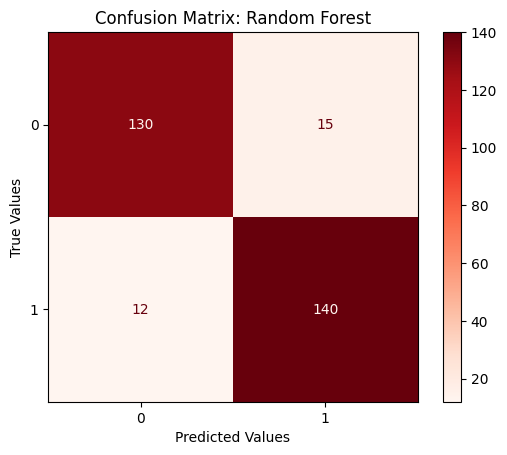

In [ ]:
cm= confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.show()

Evaluation Metrics

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

rrf_probs = [0 for _ in range(len(y_test))]
rfrf_probs = rfc.predict_proba(X_test)

rfrf_probs = rfrf_probs[:, 1]

rfrf_auc = roc_auc_score(y_test, rfrf_probs)
print('Random Forest: AUC_ROC = %.3f' % (rfrf_auc))

Random Forest: AUC_ROC = 0.960


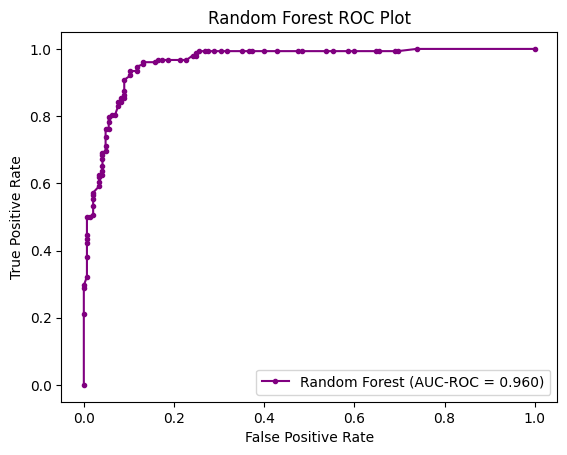

In [ ]:
rfrf_fpr, rfrf_tpr, _ = roc_curve(y_test, rfrf_probs)

plt.plot(rfrf_fpr, rfrf_tpr, marker='.', label='Random Forest (AUC-ROC = %0.3f)' % rfrf_auc, color='purple')
# Title
plt.title('Random Forest ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #

plt.savefig('Random Forest ROC Plot')

# Show plot
plt.show()

XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=10)
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=10, ...)

In [ ]:
y_pred=xgb.predict(X_test)

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       145
           1       0.51      1.00      0.68       152

    accuracy                           0.51       297
   macro avg       0.26      0.50      0.34       297
weighted avg       0.26      0.51      0.35       297



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion Matrix

In [ ]:
confusion_matrix(y_test,y_pred)

array([[  0, 145],
       [  0, 152]])

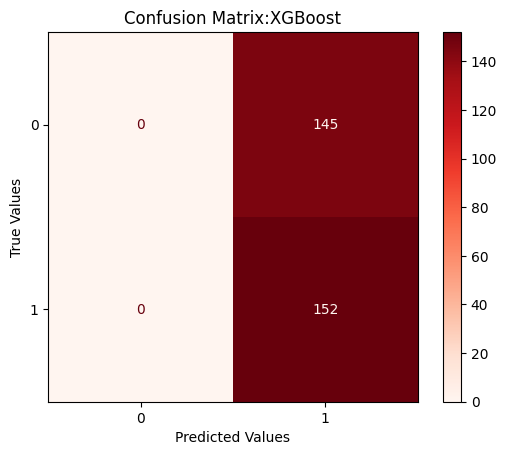

In [ ]:
cm= confusion_matrix(y_test,y_pred)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix:XGBoost')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.show()


In [ ]:
rxgb_probs = [0 for _ in range(len(y_test))]
rfxgb_probs = xgb.predict_proba(X_test)

rfxgb_probs = rfxgb_probs[:, 1]

rfxgb_auc = roc_auc_score(y_test, rfxgb_probs)
print('XGBoost: AUC_ROC = %.3f' % (rfxgb_auc))

XGBoost: AUC_ROC = 0.711


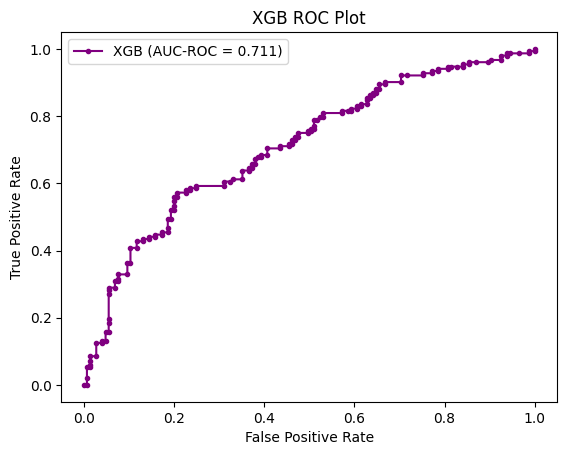

In [ ]:
rfxgb_fpr, rfxgb_tpr, _ = roc_curve(y_test, rfxgb_probs)

plt.plot(rfxgb_fpr, rfxgb_tpr, marker='.', label='XGB (AUC-ROC = %0.3f)' % rfxgb_auc, color='purple')
# Title
plt.title('XGB ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #

plt.savefig('XGBoost ROC Plot')

# Show plot
plt.show()


KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train,y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn5.predict(X_test)


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       145
           1       0.89      0.83      0.86       152

    accuracy                           0.86       297
   macro avg       0.86      0.86      0.86       297
weighted avg       0.86      0.86      0.86       297



Confusion Matrix

In [ ]:
confusion_matrix(y_test,y_pred)


array([[130,  15],
       [ 26, 126]])

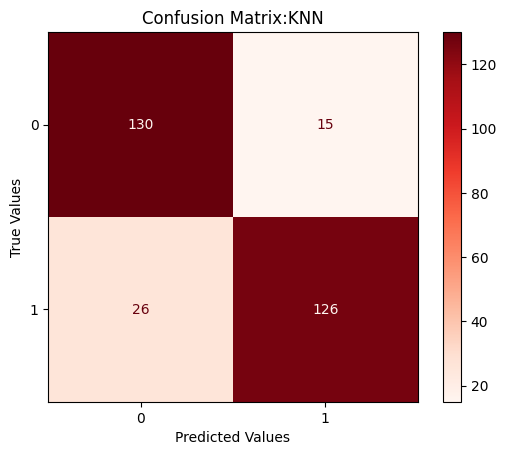

In [ ]:
cm= confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix:KNN')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.show()

In [ ]:
rknn_probs = [0 for _ in range(len(y_test))]
rfknn_probs = knn5.predict_proba(X_test)

rfknn_probs = rfknn_probs[:, 1]

rfknn_auc = roc_auc_score(y_test, rfknn_probs)
print('KNN: AUC_ROC = %.3f' % (rfknn_auc))

KNN: AUC_ROC = 0.929


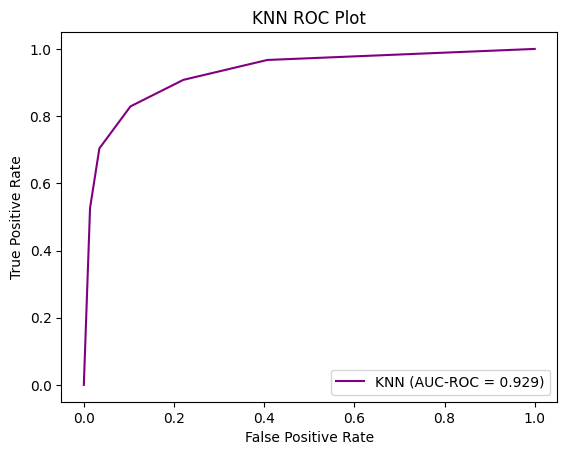

In [ ]:
rfknn_fpr, rfknn_tpr,_ = roc_curve(y_test, rfknn_probs)

plt.plot(rfknn_fpr, rfknn_tpr, label='KNN (AUC-ROC = %0.3f)' % rfknn_auc, color='purple')
# Title
plt.title('KNN ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #

plt.savefig('KNN ROC Plot')

# Show plot
plt.show()

Logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred=lr.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.86      0.87       145
           1       0.87      0.88      0.87       152

    accuracy                           0.87       297
   macro avg       0.87      0.87      0.87       297
weighted avg       0.87      0.87      0.87       297



Confusion Matrix

In [ ]:
confusion_matrix(y_test,y_pred)

array([[125,  20],
       [ 19, 133]])

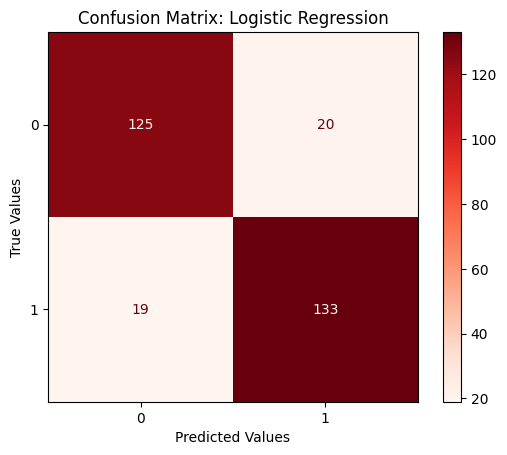

In [ ]:
cm= confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.show()


In [ ]:
rlr_probs = [0 for _ in range(len(y_test))]
rflr_probs = lr.predict_proba(X_test)

rflr_probs = rflr_probs[:, 1]

rflr_auc = roc_auc_score(y_test, rflr_probs)
print('Logistic Regression: AUC_ROC = %.3f' % (rflr_auc))

Logistic Regression: AUC_ROC = 0.927


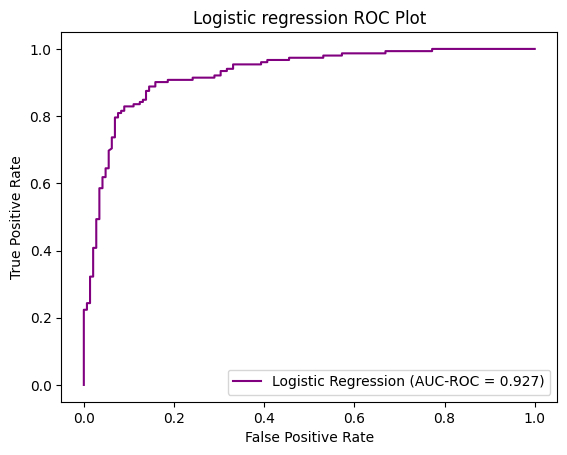

In [ ]:
rflr_fpr, rflr_tpr, _ = roc_curve(y_test, rflr_probs)

plt.plot(rflr_fpr, rflr_tpr, label='Logistic Regression (AUC-ROC = %0.3f)' % rflr_auc, color='purple')
# Title
plt.title('Logistic regression ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #

plt.savefig('Logistic Regression ROC Plot')

# Show plot
plt.show()

Desicion Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtr = DecisionTreeClassifier(criterion = 'gini', random_state = 1)

In [ ]:
dtr.fit(X_train, y_train)
y_pred=dtr.predict(X_test)

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86       145
           1       0.87      0.86      0.86       152

    accuracy                           0.86       297
   macro avg       0.86      0.86      0.86       297
weighted avg       0.86      0.86      0.86       297



Confusion Matrix

In [ ]:
confusion_matrix(y_test,y_pred)

array([[125,  20],
       [ 22, 130]])

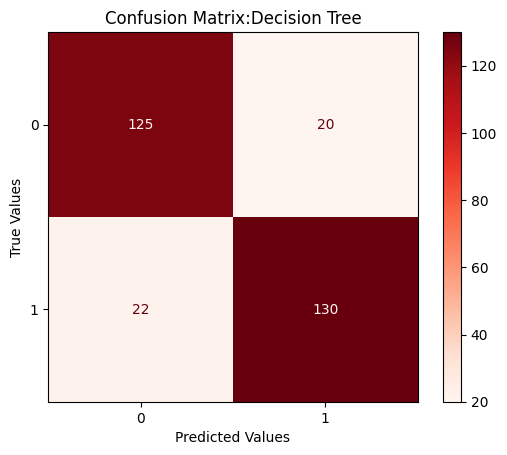

In [ ]:
cm= confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix:Decision Tree')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.show()

In [ ]:
rdt_probs = [0 for _ in range(len(y_test))]
rfdt_probs = dtr.predict_proba(X_test)

rfdt_probs = rfdt_probs[:, 1]

rfdt_auc = roc_auc_score(y_test, rfdt_probs)
print('Decision Tree: AUC_ROC = %.3f' % (rfdt_auc))


Decision Tree: AUC_ROC = 0.858


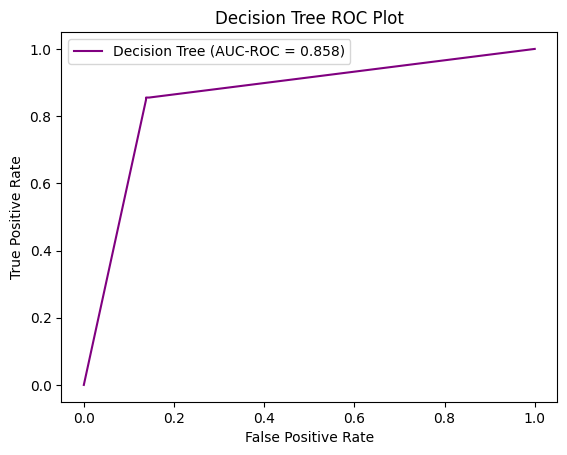

In [ ]:
rfdt_fpr, rfdt_tpr, _ = roc_curve(y_test, rfdt_probs)

plt.plot(rfdt_fpr, rfdt_tpr, label='Decision Tree (AUC-ROC = %0.3f)' % rfdt_auc, color='purple')
# Title
plt.title('Decision Tree ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #

plt.savefig('Decision Tree ROC Plot')

# Show plot
plt.show()

ANN

In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from keras.models import Sequential

In [ ]:
model = Sequential()

model.add(Dense(16, input_dim=881, activation='relu'))

model.add(Dense(8, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(X_train, y_train, epochs=200, batch_size=10)

Epoch 1/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6883 - loss: 0.6265
Epoch 2/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8366 - loss: 0.3821
Epoch 3/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8746 - loss: 0.3057
Epoch 4/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8664 - loss: 0.2795
Epoch 5/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9039 - loss: 0.2311
Epoch 6/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9029 - loss: 0.2240
Epoch 7/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9159 - loss: 0.1922
Epoch 8/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9210 - loss: 0.1741
Epoch 9/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9328 - loss: 0.1630
Epoch 10/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9435 - loss: 0.1443
Epoch 11/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9364 - loss: 0.1501
Epoch 12/200
119/119 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
y_pred = model.predict(X_test).round()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[126,  19],
       [ 17, 135]])

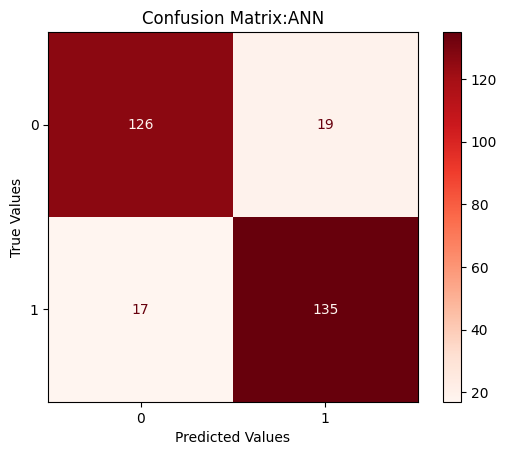

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm= confusion_matrix(y_test,y_pred)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix:ANN')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.show()


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.87      0.88       145
           1       0.88      0.89      0.88       152

    accuracy                           0.88       297
   macro avg       0.88      0.88      0.88       297
weighted avg       0.88      0.88      0.88       297



In [ ]:
print("Accuracy:",accuracy_score(y_test,y_pred))


Accuracy: 0.8787878787878788


In [ ]:
rfann_auc = roc_auc_score(y_test, y_pred)
print('NN: AUC_ROC = %.3f' % (rfann_auc))

NN: AUC_ROC = 0.879


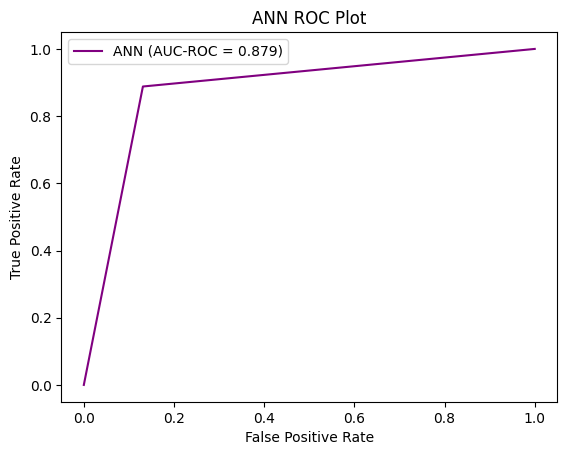

In [ ]:
rfann_fpr, rfann_tpr, _ = roc_curve(y_test, y_pred)

plt.plot(rfann_fpr, rfann_tpr, label='ANN (AUC-ROC = %0.3f)' % rfann_auc, color='purple')
# Title
plt.title('ANN ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #

plt.savefig('ANN ROC Plot')

# Show plot
plt.show()

In [ ]:
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, _ = roc_curve(y_test, random_probs, pos_label=1)

All ROC plots Combined.

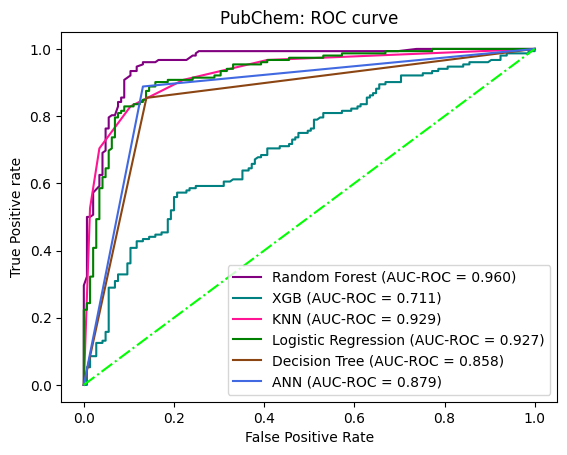

In [ ]:
import matplotlib.pyplot as plt


# plot roc curves

plt.plot(rfrf_fpr, rfrf_tpr,  label='Random Forest (AUC-ROC = %0.3f)' % rfrf_auc, color='purple')
plt.plot(rfxgb_fpr, rfxgb_tpr,  label='XGB (AUC-ROC = %0.3f)' % rfxgb_auc, color='teal')
plt.plot(rfknn_fpr, rfknn_tpr, label='KNN (AUC-ROC = %0.3f)' % rfknn_auc, color='deeppink')
plt.plot(rflr_fpr, rflr_tpr, label='Logistic Regression (AUC-ROC = %0.3f)' % rflr_auc, color='green')
plt.plot(rfdt_fpr, rfdt_tpr, label='Decision Tree (AUC-ROC = %0.3f)' % rfdt_auc, color='saddlebrown')
plt.plot(rfann_fpr, rfann_tpr, label='ANN (AUC-ROC = %0.3f)' % rfann_auc, color='royalblue')


plt.plot(p_fpr, p_tpr, linestyle='-.', color='lime')

# title
plt.title('PubChem: ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.legend(loc='best')
plt.savefig('pubchem: ROC curve',dpi=300)
plt.show();

Save model

In [ ]:
import pickle

In [ ]:
rfc

RandomForestClassifier(random_state=25)

In [ ]:
pickle.dump(rfc, open('rfc_91.pkl', 'wb'))

In [ ]:
##-----------##

Predict New Compounds and **XAI**

In [ ]:
pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.8/32.8 MB 51.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import rdkit
from rdkit import Chem
from rdkit.Chem import PandasTools

import os
from rdkit import RDConfig

import numpy as np
import pandas as pd

Final Molecular Docked Compounds

In [ ]:
sdfFile = ('her2_final.sdf')

In [ ]:
df_n = PandasTools.LoadSDF(sdfFile,smilesName='SMILES',molColName='Molecule',
           includeFingerprints=True)

,ADMET_Absorption_Level,ADMET_AlogP98,ADMET_BBB,ADMET_BBB_Level,ADMET_EXT_CYP2D6,ADMET_EXT_CYP2D6#Prediction,ADMET_EXT_CYP2D6_Applicability,ADMET_EXT_CYP2D6_Applicability#MD,ADMET_EXT_CYP2D6_Applicability#MDpvalue,ADMET_EXT_Hepatotoxic,...,Num_H_Acceptors_Lipinski,Num_H_Donors,Num_H_Donors_Lipinski,Num_RotatableBonds,Pharmprint,Pharmtype,RelativeEnergy,ID,SMILES,Molecule
0,0,4.454,-0.083,2,-3.76187,false,OPS PC15 out of range. Value: -2.8393. Trainin...,21.134,1.84923e-13,-5.78613,...,6,2,2,10,'11111',5,8.98227,Compound217,COC(=O)[C@H](Cc1cn(CC=C(C)C)c2ccccc12)NC(=O)[C...,
1,0,4.213,-0.264,2,-6.68997,false,All properties and OPS components are within e...,9.89618,0.13563,-14.6237,...,6,3,3,6,'11111',5,9.21899,Compound52,CC1=C[C@H]2[C@H]([C@H](C)CCC[C@@H](C)[C@H]3OC[...,

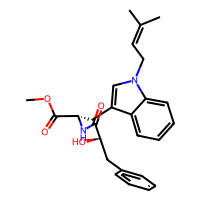
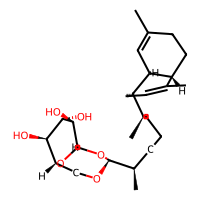

In [ ]:
df_n

In [ ]:
df_n.columns

Index(['ADMET_Absorption_Level', 'ADMET_AlogP98', 'ADMET_BBB',
       'ADMET_BBB_Level', 'ADMET_EXT_CYP2D6', 'ADMET_EXT_CYP2D6#Prediction',
       'ADMET_EXT_CYP2D6_Applicability', 'ADMET_EXT_CYP2D6_Applicability#MD',
       'ADMET_EXT_CYP2D6_Applicability#MDpvalue', 'ADMET_EXT_Hepatotoxic',
       'ADMET_EXT_Hepatotoxic#Prediction',
       'ADMET_EXT_Hepatotoxic_Applicability',
       'ADMET_EXT_Hepatotoxic_Applicability#MD',
       'ADMET_EXT_Hepatotoxic_Applicability#MDpvalue', 'ADMET_EXT_PPB',
       'ADMET_EXT_PPB#Prediction', 'ADMET_EXT_PPB_Applicability',
       'ADMET_EXT_PPB_Applicability#MD',
       'ADMET_EXT_PPB_Applicability#MDpvalue', 'ADMET_PSA_2D',
       'ADMET_Solubility', 'ADMET_Solubility_Level', 'ADMET_Unknown_AlogP98',
       'ALogP', 'AbsoluteEnergy', 'COMPOUND_ID', 'ConfNumber', 'FitValue',
       'HB_ACCEPTOR2', 'HB_DONOR3', 'HYDROPHOBIC4', 'HYDROPHOBIC5',
       'HYDROPHOBIC7', 'MapNumber', 'MappedAtoms', 'MappedFeatures',
       'MappedLocations', 'MappingID'

Deleting unwanted columns

In [ ]:
df_n1=df_n.drop(['ADMET_Absorption_Level', 'ADMET_AlogP98', 'ADMET_BBB',
       'ADMET_BBB_Level', 'ADMET_EXT_CYP2D6', 'ADMET_EXT_CYP2D6#Prediction',
       'ADMET_EXT_CYP2D6_Applicability', 'ADMET_EXT_CYP2D6_Applicability#MD',
       'ADMET_EXT_CYP2D6_Applicability#MDpvalue', 'ADMET_EXT_Hepatotoxic',
       'ADMET_EXT_Hepatotoxic#Prediction',
       'ADMET_EXT_Hepatotoxic_Applicability',
       'ADMET_EXT_Hepatotoxic_Applicability#MD',
       'ADMET_EXT_Hepatotoxic_Applicability#MDpvalue', 'ADMET_EXT_PPB',
       'ADMET_EXT_PPB#Prediction', 'ADMET_EXT_PPB_Applicability',
       'ADMET_EXT_PPB_Applicability#MD',
       'ADMET_EXT_PPB_Applicability#MDpvalue', 'ADMET_PSA_2D',
       'ADMET_Solubility', 'ADMET_Solubility_Level', 'ADMET_Unknown_AlogP98',
       'ALogP', 'AbsoluteEnergy', 'COMPOUND_ID', 'ConfNumber', 'FitValue',
       'HB_ACCEPTOR2', 'HB_DONOR3', 'HYDROPHOBIC4', 'HYDROPHOBIC5',
       'HYDROPHOBIC7', 'MapNumber', 'MappedAtoms', 'MappedFeatures',
       'MappedLocations', 'MappingID', 'Molecular_PolarSurfaceArea',
       'Molecular_Weight', 'Num_H_Acceptors', 'Num_H_Acceptors_Lipinski',
       'Num_H_Donors', 'Num_H_Donors_Lipinski', 'Num_RotatableBonds',
       'Pharmprint', 'Pharmtype', 'RelativeEnergy',
       'Molecule'],axis = 1)

In [ ]:
df_n1

,ID,SMILES
0,Compound217,COC(=O)[C@H](Cc1cn(CC=C(C)C)c2ccccc12)NC(=O)[C...
1,Compound52,CC1=C[C@H]2[C@H]([C@H](C)CCC[C@@H](C)[C@H]3OC[...


In [ ]:
df_n2 =  df_n1['SMILES']
df_n2.to_csv('mole.smi', sep='\t', index=False, header=False)
df_n2

,SMILES
0,COC(=O)[C@H](Cc1cn(CC=C(C)C)c2ccccc12)NC(=O)[C...
1,CC1=C[C@H]2[C@H]([C@H](C)CCC[C@@H](C)[C@H]3OC[...


In [ ]:

! pip install padelpy



! wget https://github.com/dataprofessor/padel/raw/main/fingerprints_xml.zip
! unzip fingerprints_xml.zip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 46.2 MB/s eta 0:00:00
--2024-12-08 06:40:57--  https://github.com/dataprofessor/padel/raw/main/fingerprints_xml.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dataprofessor/padel/main/fingerprints_xml.zip [following]
--2024-12-08 06:40:58--  https://raw.githubusercontent.com/dataprofessor/padel/main/fingerprints_xml.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10871 (11K) [application/zip]
Saving to: ‘fingerprints_xml.zip’

fingerprints_xml.zi 100%[===================>]  10.62K  --.-KB/s    in 0s      

2024-12-08 06:40:58 (91.

In [ ]:
import glob
xml_files = glob.glob("*.xml")
xml_files.sort()
xml_files

['AtomPairs2DFingerprintCount.xml',
 'AtomPairs2DFingerprinter.xml',
 'EStateFingerprinter.xml',
 'ExtendedFingerprinter.xml',
 'Fingerprinter.xml',
 'GraphOnlyFingerprinter.xml',
 'KlekotaRothFingerprintCount.xml',
 'KlekotaRothFingerprinter.xml',
 'MACCSFingerprinter.xml',
 'PubchemFingerprinter.xml',
 'SubstructureFingerprintCount.xml',
 'SubstructureFingerprinter.xml']

In [ ]:
FP_list = ['AtomPairs2DCount',
 'AtomPairs2D',
 'EState',
 'CDKextended',
 'CDK',
 'CDKgraphonly',
 'KlekotaRothCount',
 'KlekotaRoth',
 'MACCS',
 'PubChem',
 'SubstructureCount',
 'Substructure']

In [ ]:
fp = dict(zip(FP_list, xml_files))
fp

{'AtomPairs2DCount': 'AtomPairs2DFingerprintCount.xml',
 'AtomPairs2D': 'AtomPairs2DFingerprinter.xml',
 'EState': 'EStateFingerprinter.xml',
 'CDKextended': 'ExtendedFingerprinter.xml',
 'CDK': 'Fingerprinter.xml',
 'CDKgraphonly': 'GraphOnlyFingerprinter.xml',
 'KlekotaRothCount': 'KlekotaRothFingerprintCount.xml',
 'KlekotaRoth': 'KlekotaRothFingerprinter.xml',
 'MACCS': 'MACCSFingerprinter.xml',
 'PubChem': 'PubchemFingerprinter.xml',
 'SubstructureCount': 'SubstructureFingerprintCount.xml',
 'Substructure': 'SubstructureFingerprinter.xml'}

In [ ]:
from padelpy import padeldescriptor

fingerprint = 'PubChem'

fingerprint_output_file = ''.join([fingerprint,'.csv']) #Substructure.csv
fingerprint_descriptortypes = fp[fingerprint]

padeldescriptor(mol_dir='mole.smi',
                d_file=fingerprint_output_file, #'Substructure.csv'

                descriptortypes= fingerprint_descriptortypes,
                detectaromaticity=True,
                standardizenitro=True,
                standardizetautomers=True,
                threads=2,
                removesalt=True,
                log=True,
                fingerprints=True)

In [ ]:
df_n4 = pd.read_csv(fingerprint_output_file)
df_n4

,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,AUTOGEN_mole_1,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AUTOGEN_mole_2,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_n5=df_n4.drop(['Name'],axis=1)

In [ ]:
df_n5

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
rfc.predict(df_n5)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


array([0, 0])

installing LIME

In [ ]:
import numpy as np

In [ ]:
X_train = pd.DataFrame(X_train) # array to dataframe

In [ ]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=f8d3c33e48e987fdf1918201164d60e98554de23ef8ef75e5f9705d239d9972f
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


In [ ]:
import lime
import lime.lime_tabular

In [ ]:
predict_fn_rf = lambda x: rfc.predict_proba(x).astype(float)
X = X_train.values
explainer = lime.lime_tabular.LimeTabularExplainer(X,feature_names = X_train.columns,class_names=['Active=0','Inactive = 1'],kernel_width=5)

In [ ]:
X_test
X_test = pd.DataFrame(X_test) # array to dataframe

In [ ]:
X_test

,0,1,2,3,4,5,6,7,8,9,...,871,872,873,874,875,876,877,878,879,880
0,-3.298485,-3.099539,-1.675617,-0.143592,0.0,0.0,-0.116841,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.303170,0.322629,-1.675617,-0.143592,0.0,0.0,-0.116841,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.303170,0.322629,0.596795,-0.143592,0.0,0.0,-0.116841,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.303170,0.322629,0.596795,-0.143592,0.0,0.0,-0.116841,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-3.298485,-3.099539,-1.675617,-0.143592,0.0,0.0,-0.116841,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,0.303170,0.322629,0.596795,-0.143592,0.0,0.0,-0.116841,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
293,0.303170,0.322629,0.596795,-0.143592,0.0,0.0,-0.116841,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
294,0.303170,0.322629,0.596795,-0.143592,0.0,0.0,-0.116841,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
295,0.303170,0.322629,0.596795,-0.143592,0.0,0.0,-0.116841,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
y_test

,activity
567,0
1042,1
649,0
666,1
568,0
...,...
1091,1
1471,0
665,1
1056,1


In [ ]:
X_test.loc[[296]]

,0,1,2,3,4,5,6,7,8,9,...,871,872,873,874,875,876,877,878,879,880
296,0.30317,0.322629,0.596795,-0.143592,0.0,0.0,-0.116841,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.loc[[296]]

,Unnamed: 0,molecule_chembl_id,canonical_smiles,standard_value,units,activity,Name,PubchemFP0,PubchemFP1,PubchemFP2,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
296,296,CHEMBL175933,COc1cc2ncc(C#N)c(Nc3ccc(Sc4ncccn4)c(Cl)c3)c2cc...,348.0,uM,0,AUTOGEN_molecule_297,1,1,1,...,0,0,0,0,0,0,0,0,0,0


hit1_217_XAI

In [ ]:
choosen_instance = df_n5.loc[[0]].values[0]
exp = explainer.explain_instance(choosen_instance, predict_fn_rf,num_features=10)
exp.show_in_notebook(show_all=False,show_table=True)


hit2_52_XAI

In [ ]:
choosen_instance = df_n5.loc[[1]].values[0]
exp = explainer.explain_instance(choosen_instance, predict_fn_rf,num_features=10)


exp.show_in_notebook(show_all=False, show_table = True)

In [ ]:
#*******************